In [1]:
# ===== Imports =====
import torch
import numpy as np
from omegaconf import OmegaConf
import os
import sys

# Absolute path to your project root (the folder that contains `src/`)
PROJECT_ROOT = "../../iScat-diffusion"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Added to PYTHONPATH:", PROJECT_ROOT)

# Your project imports (adjust if needed)
from src.inference import load_ddpm_model, run_inference

Added to PYTHONPATH: ../../iScat-diffusion


In [29]:
# ===== Config Loader =====
def load_config(config_path):
    config = OmegaConf.load(config_path)
    return OmegaConf.to_container(config, resolve=True)


# ===== Paths =====
EXPRIMENT_NAME = "iscat_ddpm_2026-02-03_17-45-48"
CHECKPOINT_PATH = f"../experiments/{EXPRIMENT_NAME}/best_model.pt"
CONFIG_PATH = f"../experiments/{EXPRIMENT_NAME}/config.yaml"

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ===== Load config =====
config = load_config(CONFIG_PATH)


# ===== Load model =====
model = load_ddpm_model(
    checkpoint_path=CHECKPOINT_PATH,
    config=config,
    device=DEVICE
)


# ===== Inference settings =====
B = 1
C = config["data"]["z_chunk_size"]          # image channels
H = config["data"]["image_size"]
W = config["data"]["image_size"]
COND_CH = config["data"]["mask_channels"]   # number of mask classes

noise_shape = (B, C, H, W)


# # ===== Random conditioning mask =====
# # If one-hot masks were used during training
# if config["data"]["one_hot_encode"]:
#     # Random class per pixel
#     class_map = torch.randint(
#         low=0,
#         high=COND_CH,
#         size=(B, H, W)
#     )

#     # Convert to one-hot (B, C, H, W)
#     cond = torch.nn.functional.one_hot(
#         class_map, num_classes=COND_CH
#     ).permute(0, 3, 1, 2).float()
# else:
#     # Binary mask fallback
#     cond = torch.randint(0, 2, (B, 1, H, W)).float()


# # ===== Random contrast conditioning =====
# style_vals = None
# if config["model"]["contrast_conditioning"]["enabled"]:
#     # Mean in [-1, 1], std > 0
#     rand_mean = torch.empty(B).uniform_(-0.09, -0.01)
#     rand_std = torch.empty(B).uniform_(0.4, 0.95)
#     style_vals = torch.stack([rand_mean, rand_std], dim=1)

from src.datasets.dataset import iScatDataset
ds= iScatDataset(
        hdf5_path=config["data"]["dataset_folder_path"],
        classes=config["data"]["fluo_masks_indices"],
        indices=config["data"]["indices"],
        chunk_size=config["data"]["z_chunk_size"],
        normalize=config["data"]["normalize"],
        multi_class=config["data"]["multi_class"],
        one_hot_encode=config["data"]["one_hot_encode"],
        apply_augmentation=False,
    )
sample_idx = 1
sample_img, sample_mask = ds[sample_idx]
cond = sample_mask.unsqueeze(0).to(DEVICE)  # Add batch dim and move to device
style_vals = None
if config["model"]["contrast_conditioning"]["enabled"]:
    # Compute mean and std of the sample image
    img_mean = sample_img.mean()
    img_std = sample_img.std()
    style_vals = torch.tensor([[img_mean, img_std]], device=DEVICE)
# ===== Run inference =====


SAMPLING_STEPS = 350 #DDIM.
with torch.no_grad():
    x_pred = run_inference(
        model=model,
        noise_shape=noise_shape,
        condition=cond,
        config=config,
        device=DEVICE,
        style_vals=style_vals,
        sampling_steps=SAMPLING_STEPS

    )


# ===== Results =====
print("Inference complete!")
print(f"Generated shape: {x_pred.shape}")
print(f"Condition shape: {cond.shape}")
if style_vals is not None:
    print(f"Style vals (mean, std): {style_vals.cpu().numpy()}")

Using device: cuda:0
Initializing U_Net with img_ch=32, cond_ch=3, contrast=True
Loading weights from ../experiments/iscat_ddpm_2026-02-03_17-45-48/best_model.pt
Inference complete!
Generated shape: torch.Size([1, 32, 256, 256])
Condition shape: torch.Size([1, 3, 256, 256])
Style vals (mean, std): [[-0.04182537  0.82589644]]


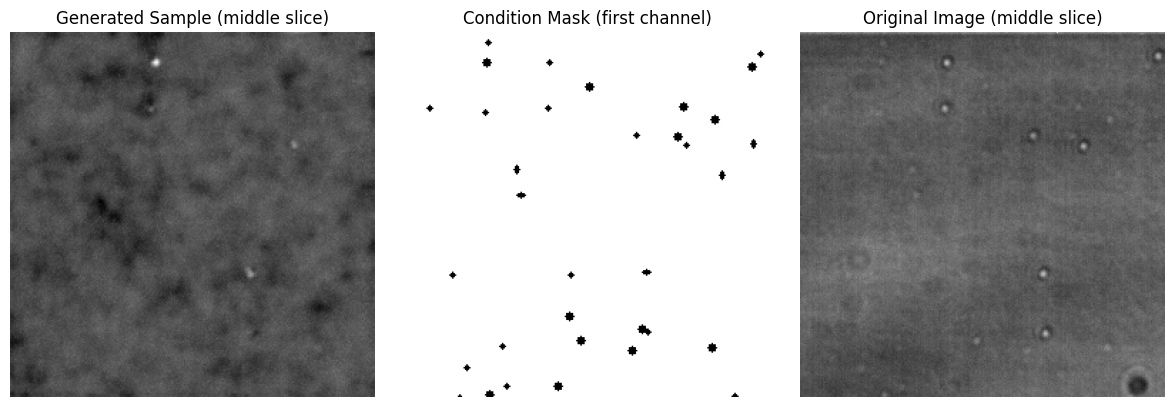

In [30]:
import matplotlib.pyplot as plt

# Show middle z-slice
mid = x_pred.shape[1] // 2

img = x_pred[0, mid].cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(img, cmap="gray", vmin=img.min(), vmax=img.max())
ax[0].set_title("Generated Sample (middle slice)")
ax[0].axis("off")

ax[1].imshow(cond[0, 0].cpu().numpy(), cmap="gray")
ax[1].set_title("Condition Mask (first channel)")
ax[1].axis("off")

ax[2].imshow(sample_img[mid].cpu().numpy(), cmap="gray", vmin=sample_img.min(), vmax=sample_img.max())
ax[2].set_title("Original Image (middle slice)")
ax[2].axis("off")

plt.tight_layout()
plt.show()
